In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
from  torch.optim.lr_scheduler import StepLR

In [33]:
# 1. Define the regression model
class TrackRegressor(nn.Module):
    def __init__(self, N):
        super(TrackRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(N, 64),
            nn.ELU(),
            nn.Linear(64, 64),
            nn.ELU(),
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x2 = x.clone()
        x2[:, 0] = (torch.abs(x[:, 0]) - 1.5) / 1.5
        x2[:, 1] = torch.log(1 / x[:, 1]) / 14  # 11
        x2[:, 2] = (x[:, 2] + np.pi) / (2 * np.pi)
        x2[:, 3] = (1 / x[:, 3]) / 20000 # 50000
        x2[:, 4] = x[:, 2] / 200 # 120
        x2[:, 5] = torch.log(x[:, 5]) / 4
        x2[:, 6] = x[:, 3] / 5 + 1e-3
        return torch.exp(self.net(x2))

# 2. Training function with validation
def train_model(model, train_loader, val_loader, num_epochs=100, learning_rate=1e-3):
    criterion = nn.SmoothL1Loss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = StepLR(optimizer, step_size=30, gamma=0.5)
    
    plot_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for inputs, targets, weights in train_loader:
            inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)*100
            weighted_loss = (loss.squeeze() * weights).mean()
            weighted_loss.backward()
            optimizer.step()
            train_loss += weighted_loss.item() * inputs.size(0) # .item()

        scheduler.step()
        
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets, weights in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)*100
                weighted_loss = (loss.squeeze() * weights).mean()
#                 weighted_loss.backward()
                val_loss += weighted_loss.item() * inputs.size(0) #.item()
        val_loss /= len(val_loader.dataset)
        
        plot_loss.append([train_loss, val_loss])
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']}")
        
    return plot_loss

# 3. Evaluation + visualization
def visualize_predictions(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, targets, weights in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            y_true.append(targets.numpy())
            y_pred.append(outputs.cpu().numpy())
    
    y_true = np.vstack(y_true).flatten()
    y_pred = np.vstack(y_pred).flatten()
    
#     y_true = np.exp(y_true) - 1e-3 
#     y_pred = np.exp(y_pred) - 1e-3 

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\nTest Metrics:")
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    # Scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("True R")
    plt.ylabel("Predicted R")
    plt.title("Predicted vs. True R")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("True R")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Residual histogram
    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=30, edgecolor='k')
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
# 4. plot the losses
def plot_loss(points):
    
    train = np.array(points).T[0]
    val = np.array(points).T[1]
    epochs = np.linspace(1, len(train), len(train))
    
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train, color="red", label="training")
    plt.plot(epochs, val, color="dodgerblue", label="validation")
    plt.xlabel("epochs")
    plt.ylabel("value")
    plt.title("Loss")
    plt.legend()
    plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

(9, 17364)
(15177, 9)


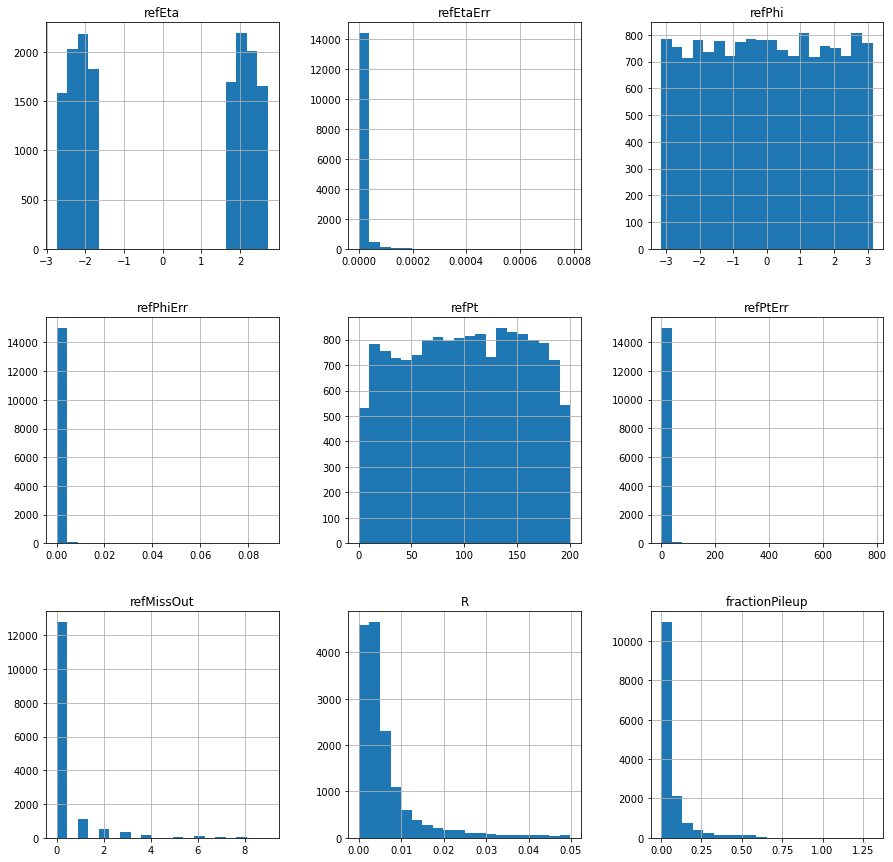

In [4]:
# refEta, refEtaErr, refPhi, refPhiErr, refPt, refMissOut, d1_sorted[idx_R], fractionPileup[idx_R]]
data = np.loadtxt("dataMultiPro_SC_fr1_pionPUpre4-err.txt") #dataMultiPro_SC_fr1_pionPUnew_noErr
print(data.shape)
CUT = 0.05

df = pd.DataFrame(data.T, columns=["refEta", "refEtaErr", "refPhi", "refPhiErr", "refPt", "refPtErr", "refMissOut", "R", "fractionPileup"]) #"refEtaErr","refPhiErr", 
df = df[df["R"]<CUT]
df = df[df["refPt"]<200]

# scaler = MaxAbsScaler()
# columns_to_scale = ["refEta", "refEtaErr", "refPhi", "refPhiErr", "refPt", "refMissOut"]
# df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
# scalerR = MaxAbsScaler()
# df[["R"]] = scalerR.fit_transform(df[["R"]])

# df["refPt"] = scaler.fit_transform(df["refPt"]) #  (df["refPt"] - df["refPt"].mean()) / df["refPt"].std()
# df["refEtaErr"] = np.log(df["refEtaErr"]) / df["refEtaErr"].max()
# df["refPhiErr"] = np.log(df["refPhiErr"]) / df["refPhiErr"].max()

df.hist(figsize=(15,15), bins=20)
print(df.shape)

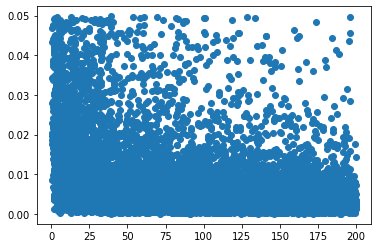

In [5]:
plt.scatter(df["refPt"], df["R"])

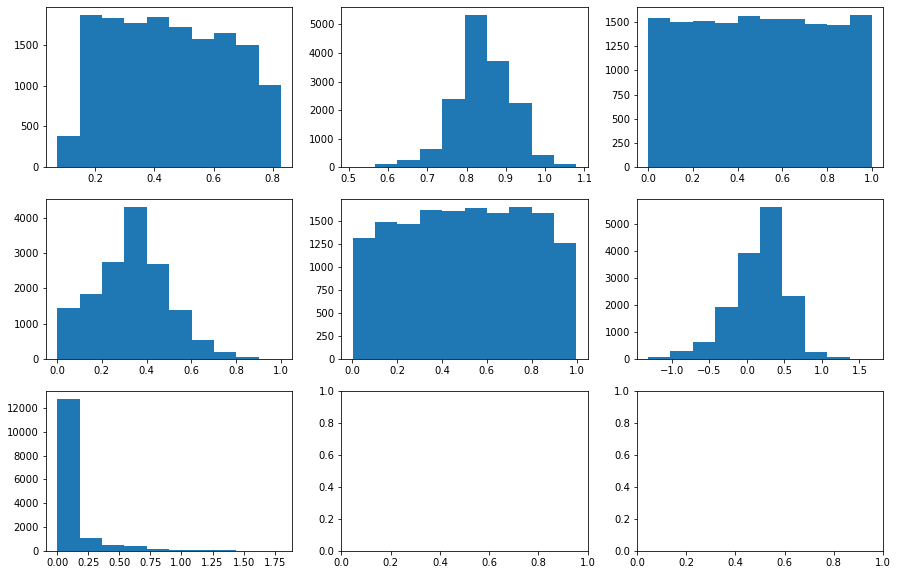

In [6]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(15, 10))
axes = axes.flat
axes[0].hist((np.abs(df['refEta']) - 1.5) / 1.5)
axes[1].hist(np.log(1 / df['refEtaErr']) /14 )
axes[2].hist((df['refPhi'] + np.pi) / (2*np.pi))
axes[3].hist(1 / df['refPhiErr'] / 20000)
axes[4].hist(df['refPt'] / 200)
axes[5].hist(np.log(df['refPtErr'])/4)
axes[6].hist(df['refMissOut'] / 5 + 1e-3)
plt.show()

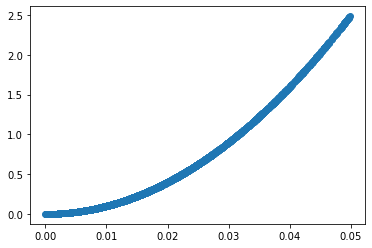

In [36]:
y = df["R"].to_numpy().astype(np.float32)

alpha = 20.0
R_max = y.max()
weights = y**2*1e3

# plt.hist(y, alpha=0.5)
plt.scatter(y, weights)

(15177, 7) (15177,)
Using device: cpu
Epoch 000, Train Loss: 4.2163, Val Loss: 2.9699, LR: 1e-05
Epoch 010, Train Loss: 0.0770, Val Loss: 0.0560, LR: 1e-05
Epoch 020, Train Loss: 0.0033, Val Loss: 0.0027, LR: 1e-05
Epoch 030, Train Loss: 0.0012, Val Loss: 0.0011, LR: 5e-06
Epoch 040, Train Loss: 0.0011, Val Loss: 0.0010, LR: 5e-06
Epoch 050, Train Loss: 0.0011, Val Loss: 0.0010, LR: 5e-06
Epoch 060, Train Loss: 0.0010, Val Loss: 0.0010, LR: 2.5e-06
Epoch 070, Train Loss: 0.0010, Val Loss: 0.0010, LR: 2.5e-06
Epoch 080, Train Loss: 0.0010, Val Loss: 0.0010, LR: 2.5e-06
Epoch 090, Train Loss: 0.0010, Val Loss: 0.0010, LR: 1.25e-06
Epoch 100, Train Loss: 0.0010, Val Loss: 0.0010, LR: 1.25e-06
Epoch 110, Train Loss: 0.0010, Val Loss: 0.0010, LR: 1.25e-06
Epoch 120, Train Loss: 0.0010, Val Loss: 0.0010, LR: 6.25e-07
Epoch 130, Train Loss: 0.0010, Val Loss: 0.0010, LR: 6.25e-07
Epoch 140, Train Loss: 0.0010, Val Loss: 0.0010, LR: 6.25e-07

Test Metrics:
RMSE: 0.0209, MAE: 0.0200, R²: -5.6641

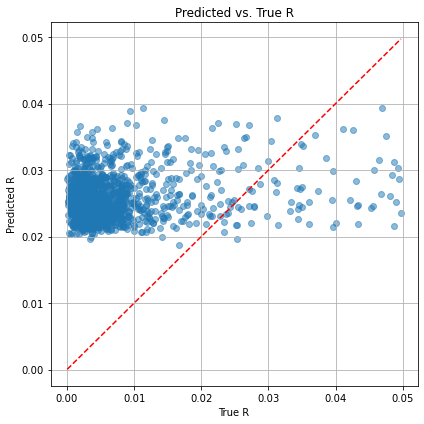

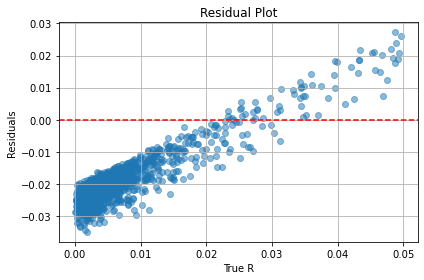

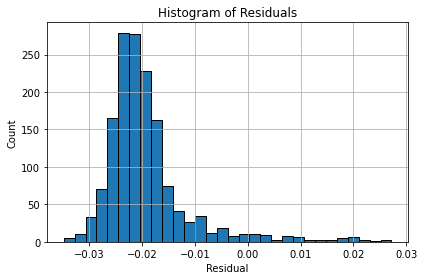

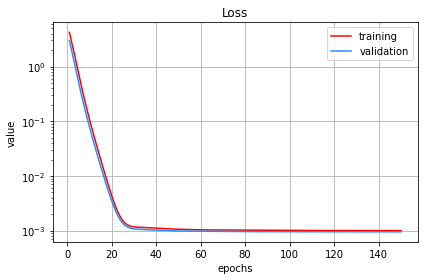

In [37]:
X = df[["refEta", "refEtaErr", "refPhi", "refPhiErr", "refPt", "refPtErr", "refMissOut"]].to_numpy().astype(np.float32)  # shape (N, 3)"refEtaErr", "refPhiErr",
y = df["R"].to_numpy().astype(np.float32)
weights_tensor = torch.tensor(weights, dtype=torch.float32)
print(X.shape, y.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1), weights_tensor)

# Split
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Instantiate model and run
model = TrackRegressor(X.shape[1]).to(device)
points_loss = train_model(model, train_loader, val_loader, num_epochs=150, learning_rate=1e-5)
visualize_predictions(model, test_loader)
plot_loss(points_loss)

(16266, 7) (16266,)
Using device: cpu
Epoch 000, Train Loss: 44.1424, Val Loss: 34.0085, LR: 1e-05
Epoch 010, Train Loss: 0.4749, Val Loss: 0.3999, LR: 1e-05
Epoch 020, Train Loss: 0.0234, Val Loss: 0.0205, LR: 1e-05
Epoch 030, Train Loss: 0.0030, Val Loss: 0.0028, LR: 5e-06
Epoch 040, Train Loss: 0.0022, Val Loss: 0.0021, LR: 5e-06
Epoch 050, Train Loss: 0.0021, Val Loss: 0.0020, LR: 5e-06
Epoch 060, Train Loss: 0.0020, Val Loss: 0.0019, LR: 2.5e-06
Epoch 070, Train Loss: 0.0019, Val Loss: 0.0018, LR: 2.5e-06
Epoch 080, Train Loss: 0.0019, Val Loss: 0.0018, LR: 2.5e-06
Epoch 090, Train Loss: 0.0019, Val Loss: 0.0018, LR: 1.25e-06
Epoch 100, Train Loss: 0.0018, Val Loss: 0.0018, LR: 1.25e-06
Epoch 110, Train Loss: 0.0018, Val Loss: 0.0017, LR: 1.25e-06
Epoch 120, Train Loss: 0.0018, Val Loss: 0.0017, LR: 6.25e-07
Epoch 130, Train Loss: 0.0018, Val Loss: 0.0017, LR: 6.25e-07
Epoch 140, Train Loss: 0.0018, Val Loss: 0.0017, LR: 6.25e-07

Test Metrics:
RMSE: 0.0064, MAE: 0.0039, R²: 0.280

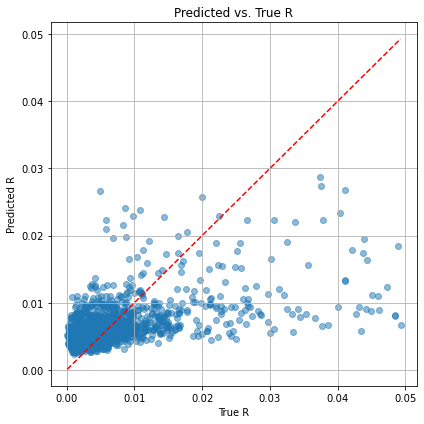

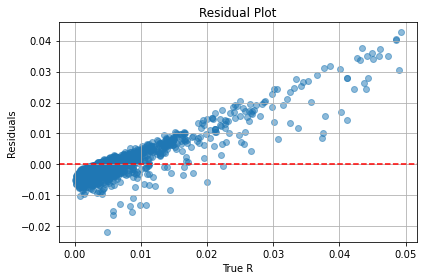

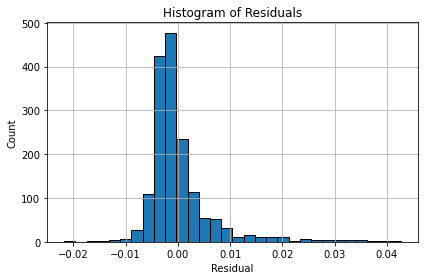

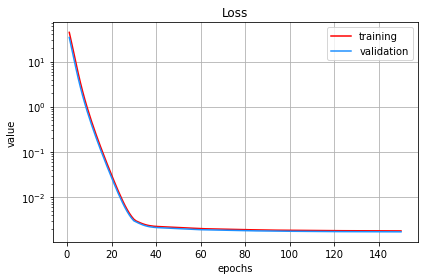

In [13]:
X = df[["refEta", "refEtaErr", "refPhi", "refPhiErr", "refPt", "refPtErr", "refMissOut"]].to_numpy().astype(np.float32)  # shape (N, 3)"refEtaErr", "refPhiErr",
y = df["R"].to_numpy().astype(np.float32)
print(X.shape, y.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))

# Split
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Instantiate model and run
model = TrackRegressor(X.shape[1]).to(device)
points_loss = train_model(model, train_loader, val_loader, num_epochs=150, learning_rate=1e-5)
visualize_predictions(model, test_loader)
plot_loss(points_loss)

## shap

In [14]:
import sys
sys.path.append('/eos/home-a/aperego/.local/lib/python3.9/site-packages')
import shap

16266
(300, 7)


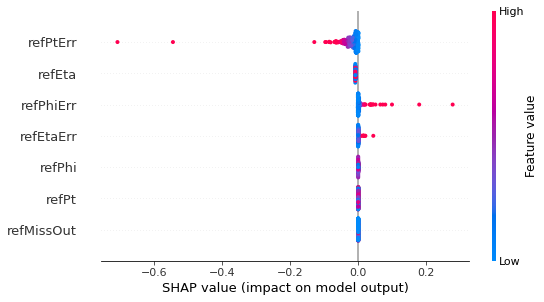

In [15]:
e = shap.DeepExplainer(
        model, 
        torch.from_numpy(
            X[np.random.choice(np.arange(len(X)), 1000, replace=False)]
        ).to(device))
x_samples = X[np.random.choice(np.arange(len(X)), 300, replace=False)]
print(len(X))
shap_values = e.shap_values(
    torch.from_numpy(x_samples).to(device),
    check_additivity=False # exp in forward is not supported for the addictivity check
)
shap_values = np.hstack(shap_values).T
print(shap_values.shape)
features = ["refEta", "refEtaErr", "refPhi", "refPhiErr", "refPt", "refPtErr", "refMissOut"] # refPhi, refPhiErr",
# dfShap = pd.DataFrame({
#     "mean_abs_shap": np.mean(np.abs(shap_values), axis=0), 
#     "stdev_abs_shap": np.std(np.abs(shap_values), axis=0), 
#     "name": features
# })
# dfShap.sort_values("mean_abs_shap", ascending=False)[:10]

shap.summary_plot(shap_values, features=x_samples, feature_names=features)

## export model

In [27]:
import torch.onnx

# Create a dummy input with the same shape and type as your actual inputs
example_inputs = torch.randn(1, X.shape[1], dtype=torch.float32, device=device)

# Export to ONNX
torch.onnx.export(
    model,                                # your trained model
    example_inputs,                          # dummy input
    "dynamic_windowCPU.onnx",               # output file name
    export_params=True,                   # store trained weights
    opset_version=17,                     # set appropriate opset (>=11 recommended)
    do_constant_folding=True,             # optimize constants
    input_names=["input"],   # "eta", "etaErr", "phi", "phiErr", "pt", "ptErr", "missingOuter"             # optional: name input
    output_names=['output'],              # optional: name output
    dynamic_axes={
        'input': {0: 'batch_size'},       # allow dynamic batch size
        'output': {0: 'batch_size'}
    }
)

print("✅ Model exported to .onnx")

✅ Model exported to .onnx


In [22]:
import onnx

onnx_model = onnx.load("dynamic_window.onnx")
onnx.checker.check_model(onnx_model)